Loading and preparing data...
Correctly classified: 9769, Misclassified: 758

Creating 13 balanced datasets...
Creating 12 full iterations + 1 oversampled iteration
Full iterations use 9096 examples
Final iteration uses remaining 673 examples + oversampling
Creating 13th iteration with oversampling...
Remaining examples for 13th iteration: 0
  Stance 2: need 323, have 0 remaining
    No remaining examples for 2, sampling from all available
  Stance 0: need 242, have 0 remaining
    No remaining examples for 0, sampling from all available
  Stance 1: need 193, have 0 remaining
    No remaining examples for 1, sampling from all available
Created 13 balanced datasets
  Dataset 1: 1516 examples, 758 correct, 758 incorrect
  Dataset 2: 1516 examples, 758 correct, 758 incorrect
  Dataset 3: 1516 examples, 758 correct, 758 incorrect
  Dataset 4: 1516 examples, 758 correct, 758 incorrect
  Dataset 5: 1516 examples, 758 correct, 758 incorrect
  Dataset 6: 1516 examples, 758 correct, 758 incorre

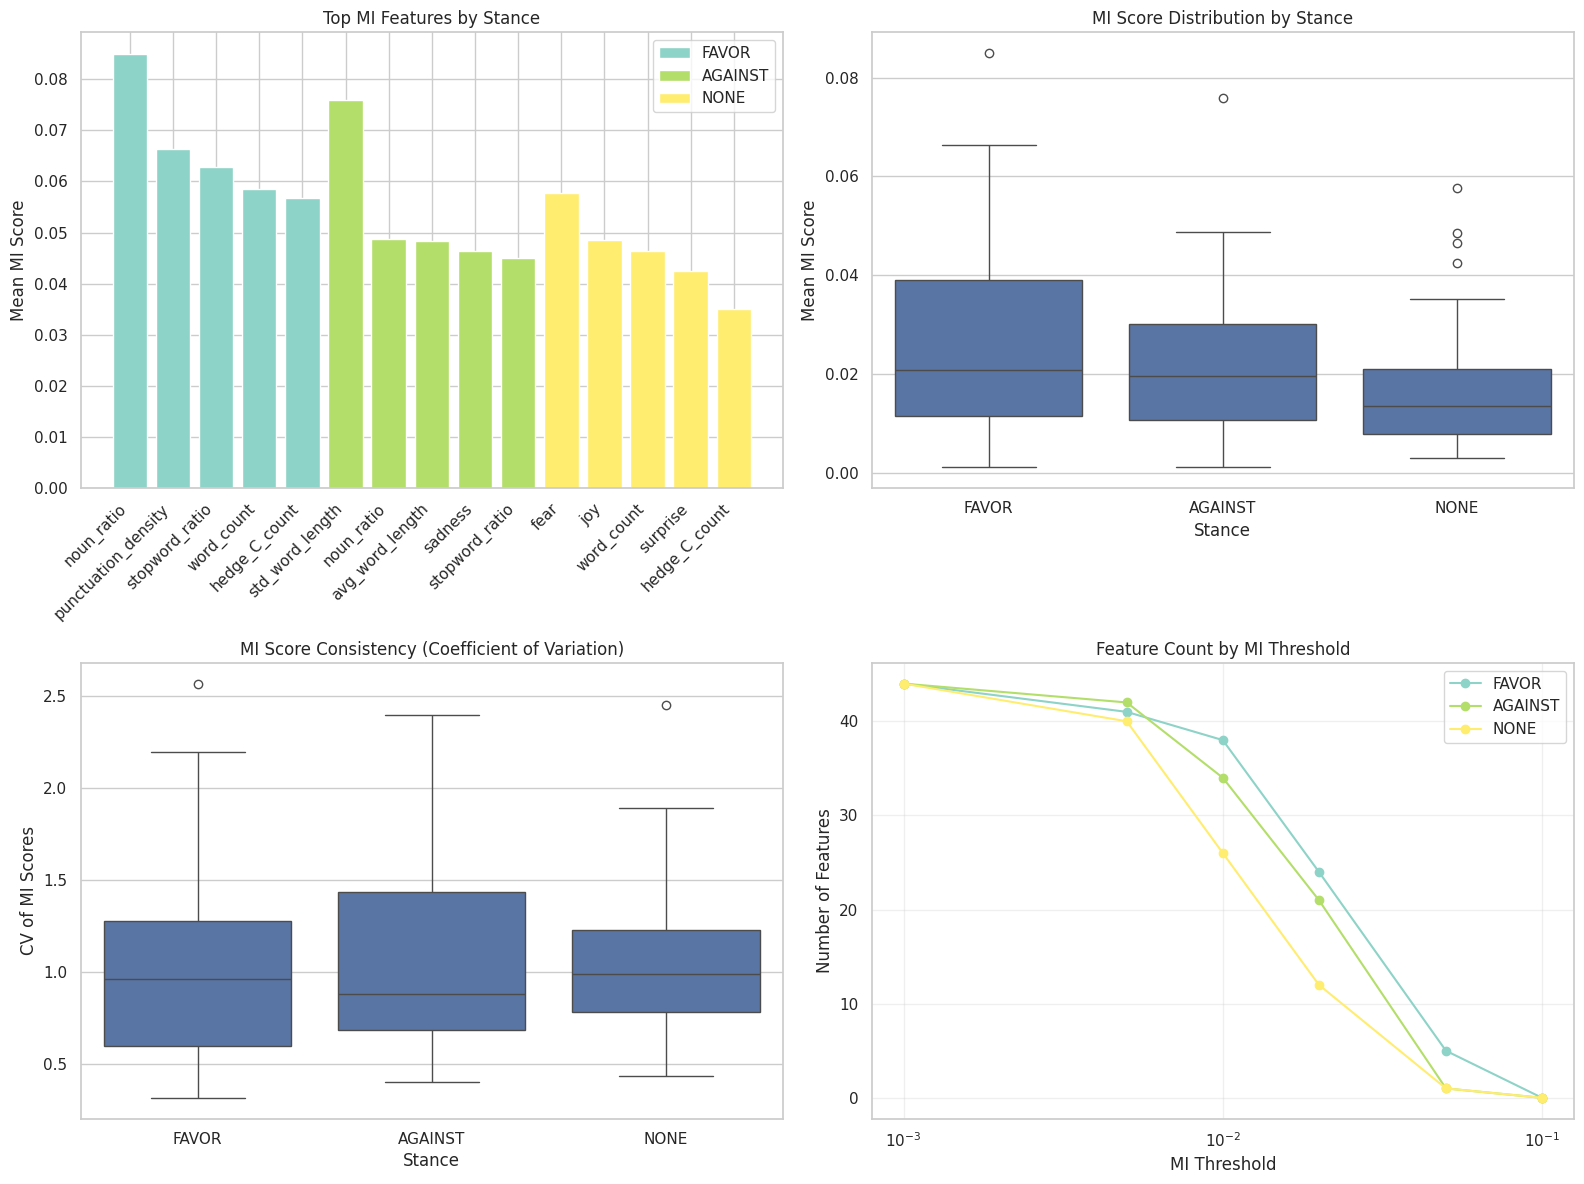

Saved MI visualizations to final_analysis_with_mi/mi_visualizations

✅ Complete analysis with MI finished!
📁 Results saved in: final_analysis_with_mi
📊 MI analysis: final_analysis_with_mi/aggregated_mi_analysis
📈 Visualizations: final_analysis_with_mi/mi_visualizations


In [7]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

def load_and_prepare_data(base_dir):
    """Load data and return separate correct and misclassified dataframes for multiple undersampling"""
    paths = ['wtwt_test_processed.csv', 'except_wtwt_test_processed_mapped_data.csv']
    indices = ['wtwt_correctly_classified_indices.npy', 'wtwt_misclassified_indices.npy',
               'except_wtwt_correctly_classified_indices.npy', 'except_wtwt_misclassified_indices.npy']

    df_wtwt = pd.read_csv(os.path.join(base_dir, paths[0]))
    df_except = pd.read_csv(os.path.join(base_dir, paths[1]))

    wtwt_correct = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[0]))]
    wtwt_mis = df_wtwt.iloc[np.load(os.path.join(base_dir, indices[1]))]
    except_correct = df_except.iloc[np.load(os.path.join(base_dir, indices[2]))]
    except_mis = df_except.iloc[np.load(os.path.join(base_dir, indices[3]))]

    df_correct = pd.concat([wtwt_correct, except_correct]).assign(label=1)
    df_mis = pd.concat([wtwt_mis, except_mis]).assign(label=0)
    
    print(f"Correctly classified: {len(df_correct)}, Misclassified: {len(df_mis)}")
    
    return df_correct.reset_index(drop=True), df_mis.reset_index(drop=True)

def create_balanced_datasets_all_data(df_correct, df_mis):
    """Create 13 balanced datasets using ALL correctly classified examples"""
    balanced_datasets = []
    misclassified_stance_counts = df_mis['stance'].value_counts()
    
    # Calculate iterations
    full_iterations = len(df_correct) // len(df_mis)
    remaining_examples = len(df_correct) % len(df_mis)
    
    print(f"Creating {full_iterations} full iterations + 1 oversampled iteration")
    print(f"Full iterations use {full_iterations * len(df_mis)} examples")
    print(f"Final iteration uses remaining {remaining_examples} examples + oversampling")
    
    # Create full iterations
    for iteration in range(full_iterations):
        df_correct_sampled_parts = []
        
        for stance in misclassified_stance_counts.index:
            stance_correct = df_correct[df_correct['stance'] == stance]
            stance_misclassified_count = misclassified_stance_counts[stance]
            
            if len(stance_correct) > 0:
                total_available = len(stance_correct)
                samples_per_iteration = total_available // full_iterations
                
                start_idx = iteration * samples_per_iteration
                end_idx = (iteration + 1) * samples_per_iteration
                
                if iteration == full_iterations - 1:
                    end_idx = total_available
                
                sampled = stance_correct.iloc[start_idx:end_idx]
                
                if len(sampled) > stance_misclassified_count:
                    sampled = sampled.sample(n=stance_misclassified_count, random_state=42+iteration)
                elif len(sampled) < stance_misclassified_count:
                    additional_needed = stance_misclassified_count - len(sampled)
                    additional = stance_correct.sample(n=additional_needed, replace=True, random_state=42+iteration)
                    sampled = pd.concat([sampled, additional])
                
                df_correct_sampled_parts.append(sampled)
        
        df_correct_sampled = pd.concat(df_correct_sampled_parts, ignore_index=True)
        df_balanced = pd.concat([df_correct_sampled, df_mis], ignore_index=True)
        balanced_datasets.append(df_balanced.sample(frac=1, random_state=42+iteration).reset_index(drop=True))
    
    # Create 13th iteration with oversampling - FIXED VERSION
    print("Creating 13th iteration with oversampling...")
    
    # Get all indices used in full iterations
    used_indices = set()
    for iteration in range(full_iterations):
        for stance in misclassified_stance_counts.index:
            stance_correct = df_correct[df_correct['stance'] == stance]
            if len(stance_correct) > 0:
                total_available = len(stance_correct)
                samples_per_iteration = total_available // full_iterations
                start_idx = iteration * samples_per_iteration
                end_idx = (iteration + 1) * samples_per_iteration
                if iteration == full_iterations - 1:
                    end_idx = total_available
                
                # Add the actual indices that were used
                used_stance_indices = stance_correct.iloc[start_idx:end_idx].index
                used_indices.update(used_stance_indices)
    
    # Get remaining examples
    remaining_examples_df = df_correct[~df_correct.index.isin(used_indices)]
    print(f"Remaining examples for 13th iteration: {len(remaining_examples_df)}")
    
    # Create 13th iteration by stance
    df_correct_13th_parts = []
    target_size = len(df_mis)
    
    for stance in misclassified_stance_counts.index:
        stance_remaining = remaining_examples_df[remaining_examples_df['stance'] == stance]
        stance_target = misclassified_stance_counts[stance]
        
        print(f"  Stance {stance}: need {stance_target}, have {len(stance_remaining)} remaining")
        
        if len(stance_remaining) > 0:
            if len(stance_remaining) >= stance_target:
                # Enough remaining examples
                sampled = stance_remaining.sample(n=stance_target, random_state=142)
            else:
                # Need to oversample
                sampled = stance_remaining.sample(n=stance_target, replace=True, random_state=142)
            df_correct_13th_parts.append(sampled)
        else:
            # No remaining examples for this stance, sample from all available
            print(f"    No remaining examples for {stance}, sampling from all available")
            stance_all = df_correct[df_correct['stance'] == stance]
            if len(stance_all) > 0:
                sampled = stance_all.sample(n=stance_target, replace=True, random_state=142)
                df_correct_13th_parts.append(sampled)
    
    # Check if we have any parts to concatenate
    if len(df_correct_13th_parts) == 0:
        print("  No stance-specific samples, using random sampling from all correct examples")
        df_correct_13th = df_correct.sample(n=target_size, replace=True, random_state=142)
    else:
        df_correct_13th = pd.concat(df_correct_13th_parts, ignore_index=True)
        
        # Ensure we have exactly the target size
        if len(df_correct_13th) < target_size:
            additional_needed = target_size - len(df_correct_13th)
            additional = df_correct.sample(n=additional_needed, replace=True, random_state=142)
            df_correct_13th = pd.concat([df_correct_13th, additional], ignore_index=True)
        elif len(df_correct_13th) > target_size:
            df_correct_13th = df_correct_13th.sample(n=target_size, random_state=142)
    
    # Create final balanced dataset
    df_balanced_13th = pd.concat([df_correct_13th, df_mis], ignore_index=True)
    balanced_datasets.append(df_balanced_13th.sample(frac=1, random_state=142).reset_index(drop=True))
    
    print(f"Created {len(balanced_datasets)} balanced datasets")
    for i, df in enumerate(balanced_datasets):
        print(f"  Dataset {i+1}: {len(df)} examples, {len(df[df['label']==1])} correct, {len(df[df['label']==0])} incorrect")
    
    return balanced_datasets

def calculate_mutual_information(df, feature_cols, target_col='label'):
    """Calculate mutual information for all features"""
    X = df[feature_cols]
    y = df[target_col]
    
    # Handle missing values
    X_filled = X.fillna(X.mean())
    
    # Calculate MI scores
    mi_scores = mutual_info_classif(X_filled, y, random_state=42)
    
    # Create results dataframe
    mi_results = pd.DataFrame({
        'feature': feature_cols,
        'mi_score': mi_scores
    }).sort_values('mi_score', ascending=False)
    
    return mi_results

def run_analysis_with_mi(df, output_dir, iteration_num):
    """Run analysis including mutual information for a single iteration"""
    stances = [("All_Stances", None), ("FAVOR", 1), ("AGAINST", 0), ("NONE", 2)]
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(eval_metric='logloss')
    }

    feature_cols = [
        c for c in df.columns
        if c not in ['target', 'text', 'stance', 'label', 'dataset', 'topic', 'split', 'index']
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    f1_results = []
    
    for stance_name, stance_val in stances:
        df_stance = df if stance_val is None else df[df['stance'] == stance_val]

        if df_stance['label'].nunique() < 2:
            continue

        # Save balanced dataset for this stance and iteration
        balanced_data_file = os.path.join(output_dir, f"balanced_data_{stance_name}.csv")
        df_stance.to_csv(balanced_data_file, index=False)

        # Calculate Mutual Information
        mi_results = calculate_mutual_information(df_stance, feature_cols)
        mi_file = os.path.join(output_dir, f"mutual_information_{stance_name}.csv")
        mi_results.to_csv(mi_file, index=False)
        print(f"  Saved MI results for {stance_name}: {len(mi_results)} features")

        X = df_stance[feature_cols]
        y = df_stance['label']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Preprocessing
        imputer = SimpleImputer(strategy='mean')
        scaler = StandardScaler()
        
        X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))
        X_test_processed = scaler.transform(imputer.transform(X_test))
        
        X_train_df = pd.DataFrame(X_train_processed, columns=feature_cols)
        X_test_df = pd.DataFrame(X_test_processed, columns=feature_cols)

        for model_name, model in models.items():
            print(f"    Training {model_name}...")
            
            # Train model
            model.fit(X_train_processed, y_train)
            y_pred = model.predict(X_test_processed)
            
            # Calculate F1 score
            f1 = f1_score(y_test, y_pred)
            f1_results.append({
                'Stance': stance_name,
                'Model': model_name,
                'F1_Score': f1,
                'Iteration': iteration_num
            })

            # Feature importance analysis
            if hasattr(model, 'coef_'):
                importance = pd.Series(model.coef_[0], index=feature_cols)
                importance = importance.reindex(importance.abs().sort_values(ascending=False).index).head(44)
            else:
                importance = pd.Series(model.feature_importances_, index=feature_cols).nlargest(44)

            # Statistical analysis of top features
            stats_results = []
            for feature in importance.index:
                correct_vals = df_stance[df_stance.label == 1][feature].dropna()
                mis_vals = df_stance[df_stance.label == 0][feature].dropna()

                if len(correct_vals) > 1 and len(mis_vals) > 1:
                    _, p_value = ttest_ind(correct_vals, mis_vals)
                    significance = '*' if p_value < 0.05 else ''
                    
                    # Get coefficient/importance value
                    coef_value = importance[feature]
                    
                    stats_results.append({
                        'feature': f"{feature}{significance}",
                        'p_value': p_value,
                        'significance': significance,
                        'correct_mean': correct_vals.mean().round(4),
                        'incorrect_mean': mis_vals.mean().round(4),
                        'correct_mean_std': f"{correct_vals.mean().round(4)} ± {correct_vals.std().round(4)}",
                        'incorrect_mean_std': f"{mis_vals.mean().round(4)} ± {mis_vals.std().round(4)}",
                        f'{model_name.replace(" ", "_")}_coef': coef_value if coef_value != 0 else np.nan
                    })

            stats_df = pd.DataFrame(stats_results)
            stats_file = os.path.join(output_dir, f"top_features_{stance_name}.csv")
            stats_df.to_csv(stats_file, index=False)

    return f1_results

def aggregate_mi_analysis(base_dir, output_dir, total_iterations=13):
    """Aggregate mutual information results across all iterations"""
    stances = ["All_Stances", "FAVOR", "AGAINST", "NONE"]
    
    print("\n" + "="*60)
    print("AGGREGATING MUTUAL INFORMATION ANALYSIS")
    print("="*60)
    
    os.makedirs(output_dir, exist_ok=True)
    
    for stance in stances:
        print(f"\nProcessing MI aggregation for {stance}...")
        stance_mi_data = {}  # feature -> list of MI scores across iterations
        
        # Collect MI scores from all iterations
        for i in range(1, total_iterations + 1):
            mi_file = os.path.join(base_dir, f"{i:02d}_iteration", f"mutual_information_{stance}.csv")
            
            if os.path.exists(mi_file):
                mi_df = pd.read_csv(mi_file)
                print(f"  Loaded iteration {i:02d}: {len(mi_df)} features")
                
                for _, row in mi_df.iterrows():
                    feature = row['feature']
                    mi_score = row['mi_score']
                    
                    if feature not in stance_mi_data:
                        stance_mi_data[feature] = []
                    stance_mi_data[feature].append(mi_score)
        
        # Aggregate MI scores across iterations
        aggregated_results = []
        for feature, mi_scores in stance_mi_data.items():
            if len(mi_scores) >= 7:  # Minimum occurrence threshold
                aggregated_results.append({
                    'feature': feature,
                    'mean_mi_score': np.mean(mi_scores),
                    'std_mi_score': np.std(mi_scores),
                    'median_mi_score': np.median(mi_scores),
                    'min_mi_score': np.min(mi_scores),
                    'max_mi_score': np.max(mi_scores),
                    'num_iterations': len(mi_scores),
                    'cv_mi_score': np.std(mi_scores) / np.mean(mi_scores) if np.mean(mi_scores) > 0 else np.inf
                })
        
        # Sort by mean MI score
        aggregated_df = pd.DataFrame(aggregated_results).sort_values('mean_mi_score', ascending=False)
        
        # Save results
        output_file = os.path.join(output_dir, f"aggregated_mutual_information_{stance}.csv")
        aggregated_df.to_csv(output_file, index=False)
        
        print(f"  Saved {len(aggregated_df)} features with aggregated MI to {output_file}")


        
def compare_mi_with_linear_models_from_iterations(base_dir, mi_output_dir, total_iterations=13):
    """Compare MI with linear model results directly from iteration folders"""
    stances = ["All_Stances", "FAVOR", "AGAINST", "NONE"]
    
    print("\n" + "="*60)
    print("COMPARING MI WITH LINEAR MODEL RESULTS FROM ITERATIONS")
    print("="*60)
    
    comparison_output_dir = os.path.join(base_dir, "mi_linear_comparison")
    os.makedirs(comparison_output_dir, exist_ok=True)
    
    for stance in stances:
        print(f"\nComparing MI vs Linear Models for {stance}...")
        
        # Load MI results
        mi_results_file = os.path.join(mi_output_dir, f"aggregated_mutual_information_{stance}.csv")
        
        if not os.path.exists(mi_results_file):
            print(f"  No MI results found for {stance}")
            continue
            
        mi_df = pd.read_csv(mi_results_file)
        
        # Collect linear model results from all iterations
        all_linear_features = {}
        
        for i in range(1, total_iterations + 1):
            linear_file = os.path.join(base_dir, f"{i:02d}_iteration", f"top_features_{stance}.csv")
            
            if os.path.exists(linear_file):
                linear_df = pd.read_csv(linear_file)
                
                for _, row in linear_df.iterrows():
                    clean_feature = row['feature'].replace('*', '')
                    
                    # Store linear model info
                    if clean_feature not in all_linear_features:
                        all_linear_features[clean_feature] = {
                            'lr_coefs': [],
                            'xgb_coefs': [],
                            'p_values': [],
                            'significances': [],
                            'occurrences': 0
                        }
                    
                    # Collect values from this iteration
                    if 'Logistic_Regression_coef' in row and not pd.isna(row['Logistic_Regression_coef']):
                        all_linear_features[clean_feature]['lr_coefs'].append(row['Logistic_Regression_coef'])
                    
                    if 'XGBoost_coef' in row and not pd.isna(row['XGBoost_coef']):
                        all_linear_features[clean_feature]['xgb_coefs'].append(row['XGBoost_coef'])
                    
                    if 'p_value' in row and not pd.isna(row['p_value']):
                        all_linear_features[clean_feature]['p_values'].append(row['p_value'])
                    
                    if 'significance' in row:
                        all_linear_features[clean_feature]['significances'].append(row['significance'])
                    
                    all_linear_features[clean_feature]['occurrences'] += 1
        
        # Create aggregated linear features for comparison
        linear_features_for_comparison = []
        for feature, data in all_linear_features.items():
            if data['occurrences'] >= 7:  # Same threshold as MI
                linear_features_for_comparison.append({
                    'feature': feature,
                    'median_lr_coef': np.median(data['lr_coefs']) if data['lr_coefs'] else np.nan,
                    'median_xgb_coef': np.median(data['xgb_coefs']) if data['xgb_coefs'] else np.nan,
                    'mean_p_value': np.mean(data['p_values']) if data['p_values'] else np.nan,
                    'significance_rate': data['significances'].count('*') / len(data['significances']) if data['significances'] else 0,
                    'linear_occurrences': data['occurrences']
                })
        
        linear_comparison_df = pd.DataFrame(linear_features_for_comparison)
        
        if len(linear_comparison_df) > 0:
            # Merge MI and linear results
            comparison_df = mi_df.merge(
                linear_comparison_df[['feature', 'median_lr_coef', 'median_xgb_coef', 'linear_occurrences']], 
                on='feature', how='outer', indicator=True
            )
            
            # Add ranking information - FIXED: use na_position instead of na_last
            comparison_df = comparison_df.sort_values('mean_mi_score', ascending=False, na_position='last')
            comparison_df['mi_rank'] = range(1, len(comparison_df) + 1)
            
            # Calculate rank correlation for overlapping features
            overlap_df = comparison_df[comparison_df['_merge'] == 'both'].copy()
            if len(overlap_df) > 1:
                overlap_df['abs_lr_coef'] = overlap_df['median_lr_coef'].abs()
                overlap_df = overlap_df.sort_values('abs_lr_coef', ascending=False, na_position='last')
                overlap_df['linear_rank'] = range(1, len(overlap_df) + 1)
                
                # Calculate correlation
                valid_for_corr = overlap_df.dropna(subset=['linear_rank', 'mi_rank'])
                if len(valid_for_corr) > 1:
                    correlation, p_value = spearmanr(valid_for_corr['linear_rank'], valid_for_corr['mi_rank'])
                    print(f"  Rank correlation between linear and MI: {correlation:.3f} (p={p_value:.3f})")
            
            # Identify complementary features
            mi_only_features = comparison_df[
                (comparison_df['_merge'] == 'right_only') & 
                (comparison_df['mean_mi_score'] >= 0.01)
            ]
            
            linear_only_features = comparison_df[comparison_df['_merge'] == 'left_only']
            
            print(f"  Features in both methods: {len(overlap_df)}")
            print(f"  High-MI features not in linear model: {len(mi_only_features)}")
            print(f"  Linear features not in MI (≥7 iterations): {len(linear_only_features)}")
            
            if len(mi_only_features) > 0:
                print(f"  Top complementary MI features: {list(mi_only_features['feature'].head(5))}")
        
        else:
            print(f"  No linear model results with ≥7 occurrences found for {stance}")
            comparison_df = mi_df.copy()
            comparison_df['_merge'] = 'mi_only'
            comparison_df['mi_rank'] = range(1, len(comparison_df) + 1)
        
        # Save comparison results
        output_file = os.path.join(comparison_output_dir, f"mi_linear_comparison_{stance}.csv")
        comparison_df.to_csv(output_file, index=False)
        
        print(f"  Saved comparison to {output_file}")

def create_mi_visualization(mi_output_dir, base_dir):
    """Create visualizations for mutual information analysis"""
    stances = ["FAVOR", "AGAINST", "NONE"]  # Exclude All_Stances for cleaner viz
    
    print("\n" + "="*60)
    print("CREATING MI VISUALIZATIONS")
    print("="*60)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Top MI features by stance
    ax1 = axes[0, 0]
    top_features_by_stance = {}
    
    for stance in stances:
        mi_file = os.path.join(mi_output_dir, f"aggregated_mutual_information_{stance}.csv")
        if os.path.exists(mi_file):
            mi_df = pd.read_csv(mi_file)
            top_features_by_stance[stance] = mi_df.head(10)
    
    if top_features_by_stance:
        stance_names = []
        mi_scores = []
        feature_names = []
        
        for stance, df in top_features_by_stance.items():
            for _, row in df.head(5).iterrows():  # Top 5 per stance
                stance_names.append(stance)
                mi_scores.append(row['mean_mi_score'])
                feature_names.append(row['feature'][:20])  # Truncate long names
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(stances)))
        stance_colors = {stance: colors[i] for i, stance in enumerate(stances)}
        bar_colors = [stance_colors[stance] for stance in stance_names]
        
        bars = ax1.bar(range(len(mi_scores)), mi_scores, color=bar_colors)
        ax1.set_title('Top MI Features by Stance')
        ax1.set_ylabel('Mean MI Score')
        ax1.set_xticks(range(len(feature_names)))
        ax1.set_xticklabels(feature_names, rotation=45, ha='right')
        
        # Create legend
        legend_elements = [plt.Rectangle((0,0),1,1, facecolor=stance_colors[stance], label=stance) 
                          for stance in stances]
        ax1.legend(handles=legend_elements)
    
    # Plot 2: MI score distribution
    ax2 = axes[0, 1]
    all_mi_scores = []
    all_stances = []
    
    for stance in stances:
        mi_file = os.path.join(mi_output_dir, f"aggregated_mutual_information_{stance}.csv")
        if os.path.exists(mi_file):
            mi_df = pd.read_csv(mi_file)
            all_mi_scores.extend(mi_df['mean_mi_score'].tolist())
            all_stances.extend([stance] * len(mi_df))
    
    if all_mi_scores:
        mi_data = pd.DataFrame({'MI_Score': all_mi_scores, 'Stance': all_stances})
        sns.boxplot(data=mi_data, x='Stance', y='MI_Score', ax=ax2)
        ax2.set_title('MI Score Distribution by Stance')
        ax2.set_ylabel('Mean MI Score')
    
    # Plot 3: Feature consistency (CV of MI scores)
    ax3 = axes[1, 0]
    cv_scores = []
    cv_stances = []
    
    for stance in stances:
        mi_file = os.path.join(mi_output_dir, f"aggregated_mutual_information_{stance}.csv")
        if os.path.exists(mi_file):
            mi_df = pd.read_csv(mi_file)
            valid_cv = mi_df[mi_df['cv_mi_score'] != np.inf]['cv_mi_score']
            cv_scores.extend(valid_cv.tolist())
            cv_stances.extend([stance] * len(valid_cv))
    
    if cv_scores:
        cv_data = pd.DataFrame({'CV_Score': cv_scores, 'Stance': cv_stances})
        sns.boxplot(data=cv_data, x='Stance', y='CV_Score', ax=ax3)
        ax3.set_title('MI Score Consistency (Coefficient of Variation)')
        ax3.set_ylabel('CV of MI Scores')
    
    # Plot 4: Number of features by MI threshold
    ax4 = axes[1, 1]
    thresholds = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
    feature_counts = {stance: [] for stance in stances}
    
    for threshold in thresholds:
        for stance in stances:
            mi_file = os.path.join(mi_output_dir, f"aggregated_mutual_information_{stance}.csv")
            if os.path.exists(mi_file):
                mi_df = pd.read_csv(mi_file)
                count = len(mi_df[mi_df['mean_mi_score'] >= threshold])
                feature_counts[stance].append(count)
            else:
                feature_counts[stance].append(0)
    
    for i, stance in enumerate(stances):
        ax4.plot(thresholds, feature_counts[stance], marker='o', label=stance, 
                color=colors[i] if 'colors' in locals() else None)
    
    ax4.set_title('Feature Count by MI Threshold')
    ax4.set_xlabel('MI Threshold')
    ax4.set_ylabel('Number of Features')
    ax4.set_xscale('log')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plots
    viz_output_dir = os.path.join(base_dir, "mi_visualizations")
    os.makedirs(viz_output_dir, exist_ok=True)
    
    plt.savefig(os.path.join(viz_output_dir, 'mutual_information_analysis.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(viz_output_dir, 'mutual_information_analysis.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved MI visualizations to {viz_output_dir}")

if __name__ == '__main__':
    base_dir = "evaluation_results"
    output_dir = "final_analysis_with_mi"

    # Load data
    print("Loading and preparing data...")
    df_correct, df_mis = load_and_prepare_data(base_dir)
    
    # Create balanced datasets
    print("\nCreating 13 balanced datasets...")
    balanced_datasets = create_balanced_datasets_all_data(df_correct, df_mis)
    
    # Create main output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Run analysis for each iteration
    print(f"\nRunning analysis with MI for {len(balanced_datasets)} iterations...")
    all_f1_results = []
    
    for iteration, df_balanced in enumerate(balanced_datasets):
        iteration_num = iteration + 1
        print(f"\n--- ITERATION {iteration_num:02d} ---")
        
        iteration_dir = os.path.join(output_dir, f"{iteration_num:02d}_iteration")
        os.makedirs(iteration_dir, exist_ok=True)
        
        # Run analysis including MI
        f1_results = run_analysis_with_mi(df_balanced, iteration_dir, iteration_num)
        all_f1_results.extend(f1_results)
    
    # Save F1 results summary
    f1_df = pd.DataFrame(all_f1_results)
    f1_summary = f1_df.groupby(['Stance', 'Model']).agg({
        'F1_Score': ['mean', 'std', 'min', 'max']
    }).round(4)
    f1_summary.columns = ['Mean_F1', 'Std_F1', 'Min_F1', 'Max_F1']
    f1_summary = f1_summary.reset_index()
    f1_summary.to_csv(os.path.join(output_dir, 'f1_scores_summary_with_mi.csv'), index=False)
    
    # Aggregate MI analysis
    mi_output_dir = os.path.join(output_dir, "aggregated_mi_analysis")
    aggregate_mi_analysis(output_dir, mi_output_dir)
    
    # Compare with linear models (if you have existing results)
    linear_output_dir = os.path.join(output_dir, "final_features")  # Adjust path as needed
    compare_mi_with_linear_models_from_iterations(output_dir, mi_output_dir)
    
    # Create visualizations
    create_mi_visualization(mi_output_dir, output_dir)
    
    print(f"\n✅ Complete analysis with MI finished!")
    print(f"📁 Results saved in: {output_dir}")
    print(f"📊 MI analysis: {mi_output_dir}")
    print(f"📈 Visualizations: {os.path.join(output_dir, 'mi_visualizations')}")